# Carnet 04 : Ingénierie du Chaos et Attaques FDIA
**Auteur :** Kaan BILGIC
**Projet :** Détection d'anomalies IoT par Machine Learning

**Objectif de ce carnet :** Ce script modélise mathématiquement trois scénarios d'attaques temporelles furtives (dérive lente, oscillation, attaque composite) et projette la trajectoire du piratage dans l'espace latent (PCA 2D) du réseau de neurones.
---

In [1]:
## 1. Initialisation de l'environnement Phase 3

import pandas as pd
import numpy as np
import joblib
import os
import glob
import tensorflow as tf
import matplotlib.pyplot as plt

print("--- Chargement des modeles de la Phase 3 ---")
model_dir = "../models"

# 1. Rechargement des "Cerveaux" et Artefacts
scaler_phase3 = joblib.load(os.path.join(model_dir, 'scaler_phase3.pkl'))
iso_forest_v2 = joblib.load(os.path.join(model_dir, 'isolation_forest_V2_3M.pkl'))
autoencoder_v2 = tf.keras.models.load_model(os.path.join(model_dir, 'autoencoder_V2_3M.keras'))
seuil_ae = joblib.load(os.path.join(model_dir, 'seuil_ae_V2.pkl'))

print(f"Modèles et Scaler chargés. Seuil de détection AE : {seuil_ae:.6f}")

# 2. Chargement de la "Victime" (Trafic 100% normal depuis l'échantillon GitHub)
df_norm_temp = pd.read_csv("../data/sample_Normal_Traffic.csv", low_memory=False)
# On prend 10 000 lignes continues pour simuler l'écoulement du temps
# On isole une victime spécifique pour avoir un flux physique stable et cohérent
df_victime = df_norm_temp[df_norm_temp['Source_Sensor'] == 'Temperature_and_Humidity'].head(10000).copy()

# 3. Nettoyage identique à la Phase finale (Stérilisation totale)
cols_to_drop = [
    'frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
    'arp.src.proto_ipv4', 'http.file_data', 'http.request.uri.query',
    'http.request.method', 'http.referer', 'http.request.full_uri',
    'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport',
    'tcp.dstport', 'udp.port', 'tcp.ack', 'tcp.seq',
    'tcp.ack_raw', 'tcp.seq_raw', 'tcp.checksum', 'icmp.checksum',
    'icmp.seq_le', 'mbtcp.trans_id', 'dns.qry.name.len', 'mqtt.conack.flags',
    'mqtt.msg', 'mqtt.protoname', 'mqtt.topic', 'Attack_label', 'Attack_type',
    'tcp.flags', 'http.content_length', 'mbtcp.len', 'mqtt.topic_len',
    'tcp.connection.syn', 'mqtt.ver', 'http.tls_port', 'mqtt.conflag.cleansess',
    'dns.qry.qu', 'mqtt.proto_len', 
    'Source_Sensor', 'Ground_Truth' 
]

X_victime_clean = df_victime.drop(columns=[c for c in cols_to_drop if c in df_victime.columns], errors='ignore')
X_victime_num = X_victime_clean.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Trafic victime prêt (Timeline continue de {X_victime_num.shape[0]} trames).")

--- Chargement des modeles de la Phase 3 ---
Modèles et Scaler chargés. Seuil de détection AE : 0.023380
Trafic victime prêt (Timeline continue de 10000 trames).


--- Lancement du Scénario 1 (Optimisé) : FDIA Slow Drift ---
-> Dérive injectée sur la variable 'tcp.len' avec une pente de 0.01 par trame.
DÉTECTION ! La tendance anormale a franchi le seuil à la trame n°7267.

Nouveau graphique 'Scenario1_Slow_Drift_Lisse.png' sauvegardé !


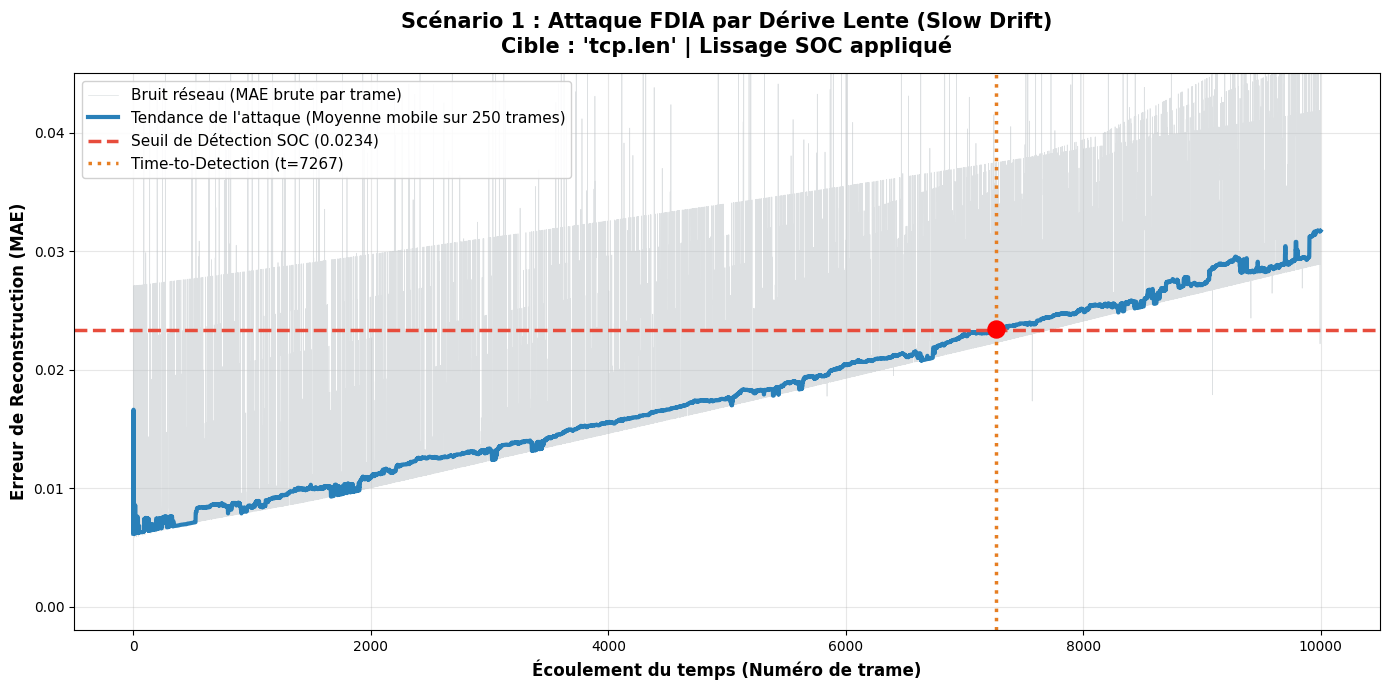

In [2]:
## 2. Scénario 1 : FDIA par Dérive Lente (Slow Drift)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Lancement du Scénario 1 (Optimisé) : FDIA Slow Drift ---")

# 1. Paramétrage de l'attaque sur une variable de délai réseau
nom_colonne = 'tcp.len'

col_cible_idx = X_victime_num.columns.get_loc(nom_colonne)

X_attaque = X_victime_num.copy()
timeline = np.arange(len(X_attaque))

# Pente ultra-furtive
pente_derive = 0.01

# Injection mathématique de la dérive
X_attaque.iloc[:, col_cible_idx] = X_attaque.iloc[:, col_cible_idx] + (pente_derive * timeline)

print(f"-> Dérive injectée sur la variable '{nom_colonne}' avec une pente de {pente_derive} par trame.")

# 2. Passage dans l'Autoencoder
X_attaque_scaled = scaler_phase3.transform(X_attaque)
reconstructions = autoencoder_v2.predict(X_attaque_scaled, batch_size=1024, verbose=0)

# Calcul du score d'anomalie BRUT (très bruité)
mae_attaque_brut = np.mean(np.abs(X_attaque_scaled - reconstructions), axis=1)

# On calcule la moyenne glissante sur 250 trames pour voir la véritable tendance de l'attaque
fenetre_lissage = 250
mae_attaque_lisse = pd.Series(mae_attaque_brut).rolling(window=fenetre_lissage, min_periods=1).median().values

# 3. Calcul du Time-to-Detection (TTD) basé sur la tendance
alertes = np.where(mae_attaque_lisse > seuil_ae)[0]

if len(alertes) > 0:
    time_to_detection = alertes[0]
    print(f"DÉTECTION ! La tendance anormale a franchi le seuil à la trame n°{time_to_detection}.")
else:
    time_to_detection = len(timeline)
    print("Évasion réussie : L'anomalie est restée sous le seuil d'alerte (Faux Négatif).")

# 4. Visualisation Temporelle (Niveau Publication Scientifique)
fig, ax1 = plt.subplots(figsize=(14, 7))

# Tracé de l'erreur brute 
ax1.plot(timeline, mae_attaque_brut, color='#bdc3c7', alpha=0.5, label="Bruit réseau (MAE brute par trame)", linewidth=0.5)

# Tracé de l'erreur lissée 
ax1.plot(timeline, mae_attaque_lisse, color='#2980b9', label=f"Tendance de l'attaque (Moyenne mobile sur {fenetre_lissage} trames)", linewidth=3)

# Seuil de détection
ax1.axhline(seuil_ae, color='#e74c3c', linestyle='--', linewidth=2.5, label=f"Seuil de Détection SOC ({seuil_ae:.4f})")

# Marquage du point de détection
if len(alertes) > 0:
    ax1.axvline(time_to_detection, color='#e67e22', linestyle=':', linewidth=2.5, label=f"Time-to-Detection (t={time_to_detection})")
    ax1.scatter(time_to_detection, mae_attaque_lisse[time_to_detection], color='red', s=150, zorder=5)

ax1.set_xlabel("Écoulement du temps (Numéro de trame)", fontweight='bold', fontsize=12)
ax1.set_ylabel("Erreur de Reconstruction (MAE)", fontweight='bold', fontsize=12)
ax1.set_title(f"Scénario 1 : Attaque FDIA par Dérive Lente (Slow Drift)\nCible : '{nom_colonne}' | Lissage SOC appliqué", fontsize=15, fontweight='bold', pad=15)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)

ax1.set_ylim(-0.002, 0.045)
plt.tight_layout()
os.makedirs("../images", exist_ok=True)
plt.savefig("../images/Scenario1_Slow_Drift_Lisse.png", dpi=300, bbox_inches='tight')
print("\nNouveau graphique 'Scenario1_Slow_Drift_Lisse.png' sauvegardé !")
plt.show()

--- Lancement du Scénario 2 : FDIA par Oscillation ---
-> Attaque sinusoïdale injectée sur 'tcp.len' (Amplitude: 85, Période: 4500).
Détection positive : L'amplitude de l'oscillation a déclenché l'alerte à la trame n°829.

Graphique 'Scenario2_Oscillation.png' généré avec succès !


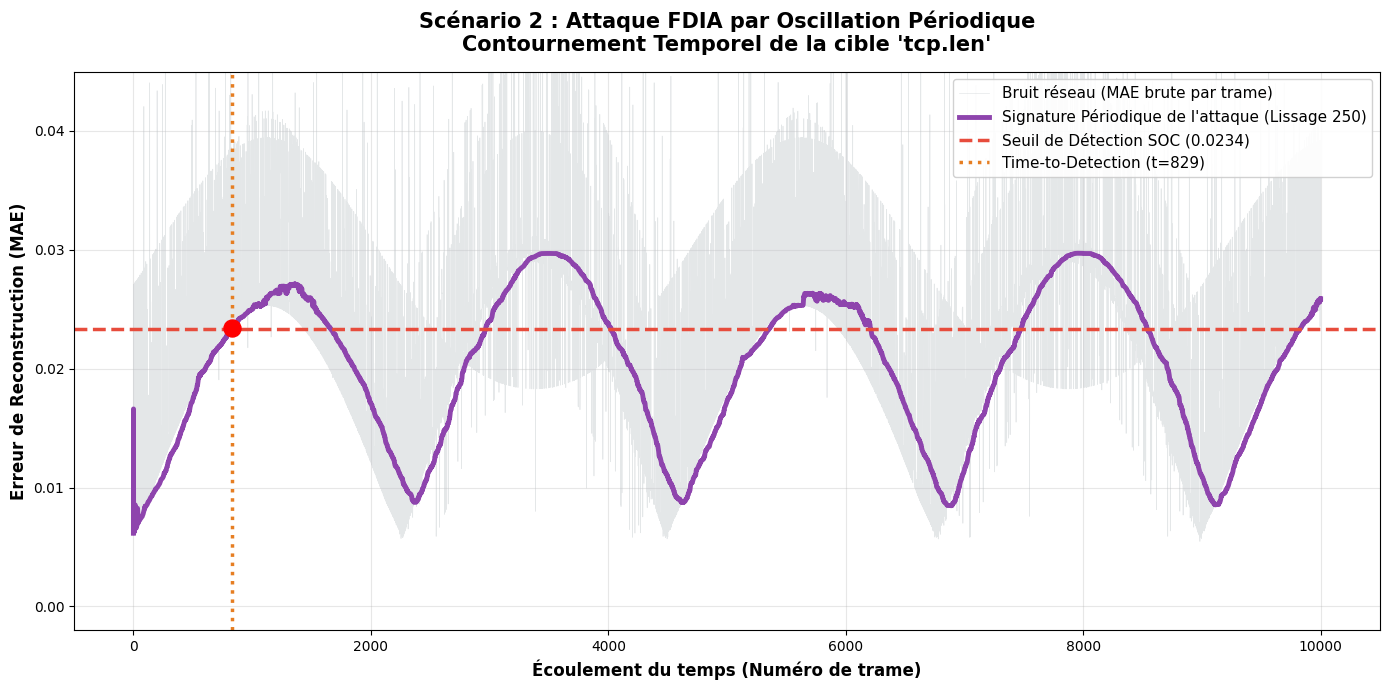

In [3]:
## 3. Scénario 2 : FDIA par Oscillation Périodique

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Lancement du Scénario 2 : FDIA par Oscillation ---")

# 1. Paramétrage de l'attaque
# On garde la même cible pour comparer avec le Scénario 1
nom_colonne = 'tcp.len' 
if nom_colonne not in X_victime_num.columns:
    nom_colonne = X_victime_num.columns[0]
    
col_cible_idx = X_victime_num.columns.get_loc(nom_colonne)
X_attaque = X_victime_num.copy()
timeline = np.arange(len(X_attaque))

# --- L'ÉQUATION DE L'ONDE ---
# Amplitude : La force de l'attaque. Si l'IA détecte, on baisse ce chiffre. Si elle ne voit rien, on l'augmente.
# Période : Le temps (en nombre de trames) pour faire un cycle complet de hausse/baisse.
amplitude = 85   # On injecte jusqu'à +120 et -120 sur la variable
periode = 4500    # Une vague complète toutes les 4500 trames

# Fonction mathématique : y = A * sin(2 * pi * (t / période))
onde_sinusoidale = amplitude * np.sin(2 * np.pi * (timeline / periode))

# Injection dans le trafic sain
X_attaque.iloc[:, col_cible_idx] = X_attaque.iloc[:, col_cible_idx] + onde_sinusoidale

print(f"-> Attaque sinusoïdale injectée sur '{nom_colonne}' (Amplitude: {amplitude}, Période: {periode}).")

# 2. Passage dans le système de défense (Autoencoder)
X_attaque_scaled = scaler_phase3.transform(X_attaque)
reconstructions = autoencoder_v2.predict(X_attaque_scaled, batch_size=1024, verbose=0)

# Calcul du score d'anomalie brute
mae_attaque_brut = np.mean(np.abs(X_attaque_scaled - reconstructions), axis=1)

# Lissage SOC 
fenetre_lissage = 250
mae_attaque_lisse = pd.Series(mae_attaque_brut).rolling(window=fenetre_lissage, min_periods=1).median().values

# 3. Évaluation du piratage
alertes = np.where(mae_attaque_lisse > seuil_ae)[0]

if len(alertes) > 0:
    time_to_detection = alertes[0]
    print(f"Détection positive : L'amplitude de l'oscillation a déclenché l'alerte à la trame n°{time_to_detection}.")
else:
    print("Évasion systémique : L'oscillation a permis de contourner le mécanisme de détection.")

# 4. Visualisation Académique
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bruit naturel
ax1.plot(timeline, mae_attaque_brut, color='#bdc3c7', alpha=0.4, label="Bruit réseau (MAE brute par trame)", linewidth=0.5)

# Signature ondulatoire de l'attaque
ax1.plot(timeline, mae_attaque_lisse, color='#8e44ad', label=f"Signature Périodique de l'attaque (Lissage {fenetre_lissage})", linewidth=3.5)

# La ligne rouge (Seuil)
ax1.axhline(seuil_ae, color='#e74c3c', linestyle='--', linewidth=2.5, label=f"Seuil de Détection SOC ({seuil_ae:.4f})")

# Si le hacker s'est fait attraper, on trace la croix de détection
if len(alertes) > 0:
    ax1.axvline(time_to_detection, color='#e67e22', linestyle=':', linewidth=2.5, label=f"Time-to-Detection (t={time_to_detection})")
    ax1.scatter(time_to_detection, mae_attaque_lisse[time_to_detection], color='red', s=150, zorder=5)

# Esthétique du graphique
ax1.set_xlabel("Écoulement du temps (Numéro de trame)", fontweight='bold', fontsize=12)
ax1.set_ylabel("Erreur de Reconstruction (MAE)", fontweight='bold', fontsize=12)
ax1.set_title(f"Scénario 2 : Attaque FDIA par Oscillation Périodique\nContournement Temporel de la cible '{nom_colonne}'", fontsize=15, fontweight='bold', pad=15)
ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)

ax1.set_ylim(-0.002, 0.045)
plt.tight_layout()
plt.savefig("../images/Scenario2_Oscillation.png", dpi=300, bbox_inches='tight')
print("\nGraphique 'Scenario2_Oscillation.png' généré avec succès !")
plt.show()

--- Lancement du Scénario 3 : FDIA Composite (Réalisme Physique) ---
-> Attaque Composite injectée sur 'tcp.len'.
   (Pente: 0.01 | Intensité du bruit: 25)
DÉTECTION ! L'usure anormale a déclenché l'alerte à la trame n°5649.

Graphique 'Scenario3_Composite.png' généré !


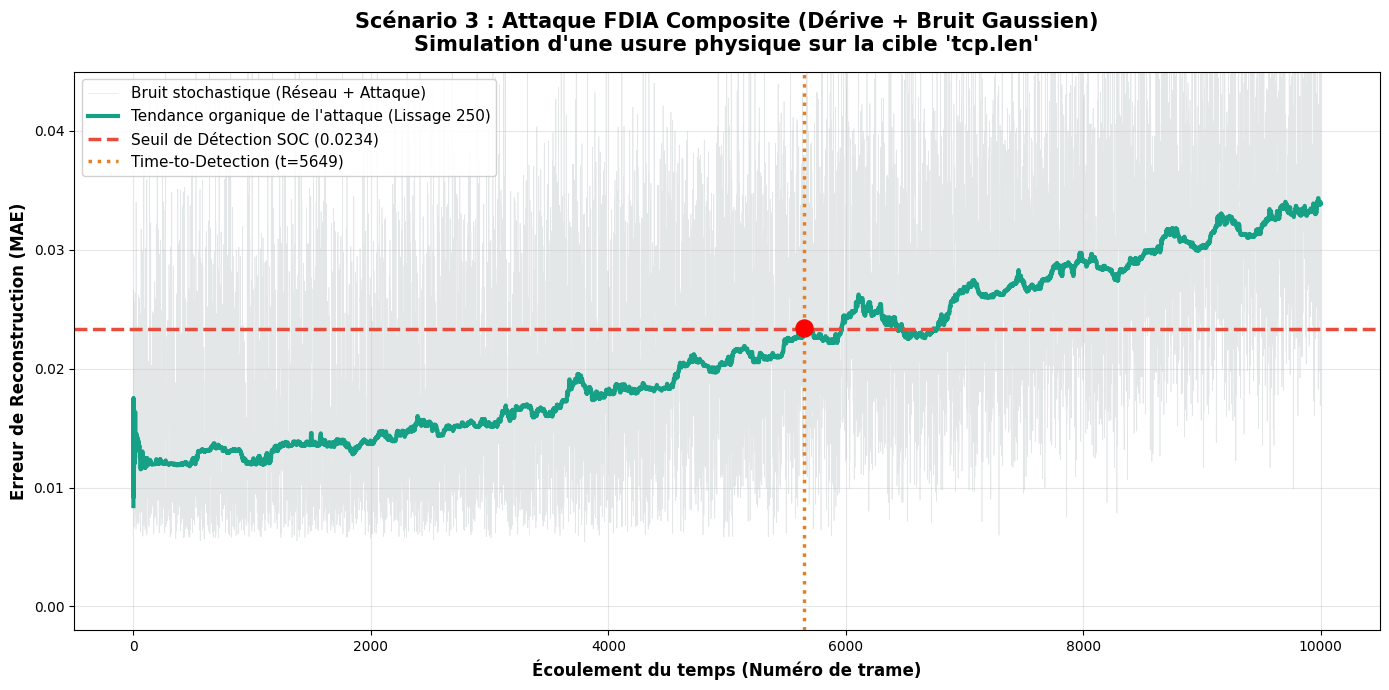

In [4]:
## 4. Scénario 3 : FDIA Composite (Dérive + Bruit Gaussien)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Lancement du Scénario 3 : FDIA Composite (Réalisme Physique) ---")

# 1. Paramétrage de la cible
nom_colonne = 'tcp.len' 
if nom_colonne not in X_victime_num.columns:
    nom_colonne = X_victime_num.columns[0]
    
col_cible_idx = X_victime_num.columns.get_loc(nom_colonne)
X_attaque = X_victime_num.copy()
timeline = np.arange(len(X_attaque))

# --- L'ÉQUATION COMPOSITE (Dérive + Chaos) ---
# 1. La Pente : On reprend la valeur qui a percé le seuil dans le Scénario 1 (0.1)
pente_derive = 0.01

# 2. Le Bruit Stochastique (Écart-type du chaos)
# Plus ce chiffre est grand, plus le capteur a l'air "cassé" et tremblant
intensite_bruit = 25

# Génération du bruit blanc via une distribution Gaussienne (Loi Normale)
np.random.seed(42) # Pour que l'aléatoire soit reproductible dans ton rapport
bruit_gaussien = np.random.normal(loc=0, scale=intensite_bruit, size=len(timeline))

# Injection composite : Vraie_Valeur + Dérive Lente + Bruit Aléatoire
X_attaque.iloc[:, col_cible_idx] = X_attaque.iloc[:, col_cible_idx] + (pente_derive * timeline) + bruit_gaussien

print(f"-> Attaque Composite injectée sur '{nom_colonne}'.")
print(f"   (Pente: {pente_derive} | Intensité du bruit: {intensite_bruit})")

# 2. Passage dans le système de défense (Autoencoder)
X_attaque_scaled = scaler_phase3.transform(X_attaque)
reconstructions = autoencoder_v2.predict(X_attaque_scaled, batch_size=1024, verbose=0)

# Calcul de l'erreur
mae_attaque_brut = np.mean(np.abs(X_attaque_scaled - reconstructions), axis=1)

# Lissage SOC (toujours 250 trames)
fenetre_lissage = 250
mae_attaque_lisse = pd.Series(mae_attaque_brut).rolling(window=fenetre_lissage, min_periods=1).median().values

# 3. Évaluation du piratage
alertes = np.where(mae_attaque_lisse > seuil_ae)[0]

if len(alertes) > 0:
    time_to_detection = alertes[0]
    print(f"DÉTECTION ! L'usure anormale a déclenché l'alerte à la trame n°{time_to_detection}.")
else:
    time_to_detection = len(timeline)
    print("Évasion réussie : La dégradation composite n'a généré aucune alerte SOC.")

# 4. Visualisation  
fig, ax1 = plt.subplots(figsize=(14, 7))

# Le bruit réseau + le bruit de l'attaque en arrière-plan
ax1.plot(timeline, mae_attaque_brut, color='#bdc3c7', alpha=0.4, label="Bruit stochastique (Réseau + Attaque)", linewidth=0.5)

# La tendance de l'attaque (qui sera désormais tremblante et organique)
ax1.plot(timeline, mae_attaque_lisse, color='#16a085', label=f"Tendance organique de l'attaque (Lissage {fenetre_lissage})", linewidth=3)

# La ligne rouge (Seuil)
ax1.axhline(seuil_ae, color='#e74c3c', linestyle='--', linewidth=2.5, label=f"Seuil de Détection SOC ({seuil_ae:.4f})")

# Marquage de la détection
if len(alertes) > 0:
    ax1.axvline(time_to_detection, color='#e67e22', linestyle=':', linewidth=2.5, label=f"Time-to-Detection (t={time_to_detection})")
    ax1.scatter(time_to_detection, mae_attaque_lisse[time_to_detection], color='red', s=150, zorder=5)

# Esthétique du graphique
ax1.set_xlabel("Écoulement du temps (Numéro de trame)", fontweight='bold', fontsize=12)
ax1.set_ylabel("Erreur de Reconstruction (MAE)", fontweight='bold', fontsize=12)
ax1.set_title(f"Scénario 3 : Attaque FDIA Composite (Dérive + Bruit Gaussien)\nSimulation d'une usure physique sur la cible '{nom_colonne}'", fontsize=15, fontweight='bold', pad=15)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)

ax1.set_ylim(-0.002, 0.045)
plt.tight_layout()
plt.savefig("../images/Scenario3_Composite.png", dpi=300, bbox_inches='tight')
print("\nGraphique 'Scenario3_Composite.png' généré !")
plt.show()

--- Lancement de l'Analyse de l'Espace Latent (Projection des représentations internes) ---
-> Goulot d'étranglement identifié à la couche 4 (dense_3).

Cartographie 'Latent_Space_Trajectory.png' générée avec succès !


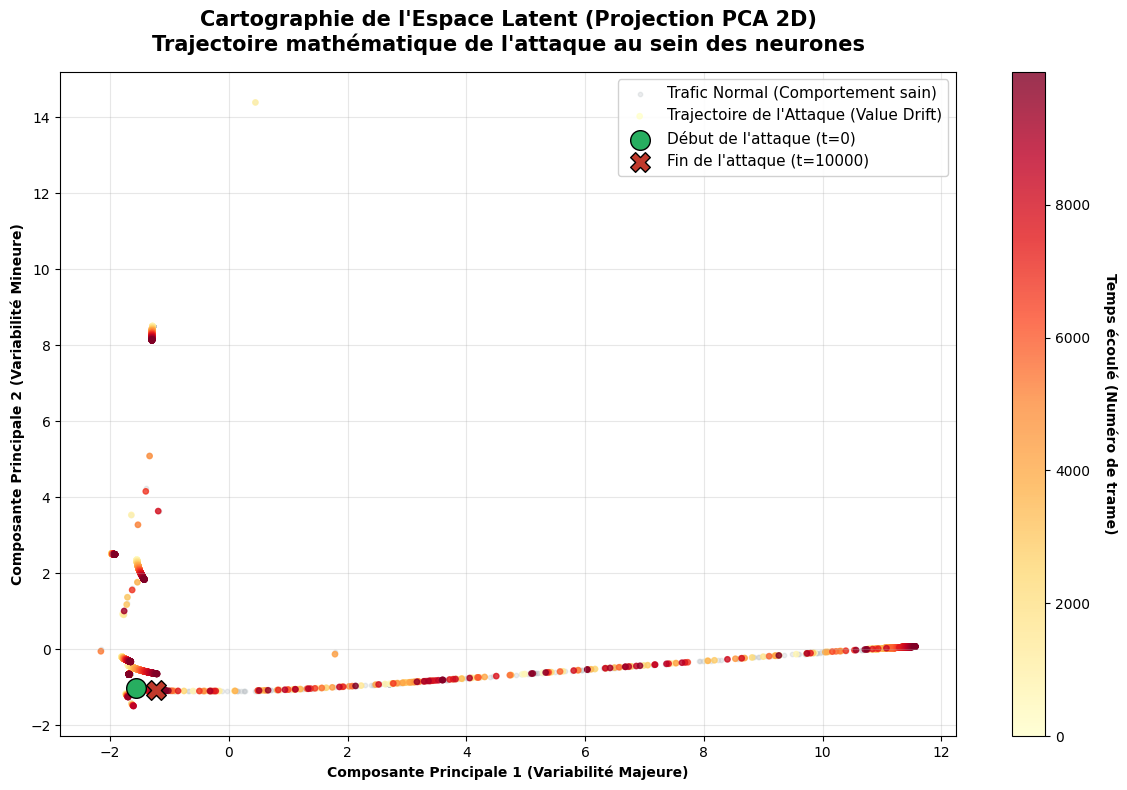

In [5]:
## 5. Visualisation dans l'Espace Latent (PCA 2D)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tensorflow as tf

print("--- Lancement de l'Analyse de l'Espace Latent (Projection des représentations internes) ---")

# 1. Extraction de l'Encodeur (La première moitié de l'Autoencoder)
# On cherche automatiquement la couche "goulot d'étranglement" (la plus petite)
tailles_couches = [np.prod(layer.output.shape[1:]) if layer.output.shape[1:] is not None else float('inf') for layer in autoencoder_v2.layers]
index_bottleneck = np.argmin(tailles_couches) 
encodeur = tf.keras.Sequential(autoencoder_v2.layers[:index_bottleneck + 1])
print(f"-> Goulot d'étranglement identifié à la couche {index_bottleneck} ({autoencoder_v2.layers[index_bottleneck].name}).")

# 2. Préparation des données (Normal vs Attaque)
# On compresse le trafic 100% normal (la victime)
X_normal_scaled = scaler_phase3.transform(X_victime_num)

# On recrée rapidement l'attaque pure (Dérive lente - Scénario 1 avec pente de 0.1)
# On utilise celle-ci car c'est la plus visuelle pour comprendre le déplacement mathématique
X_attaque_latent = X_victime_num.copy()
col_cible_idx = X_victime_num.columns.get_loc('tcp.len')
timeline = np.arange(len(X_attaque_latent))
X_attaque_latent.iloc[:, col_cible_idx] = X_attaque_latent.iloc[:, col_cible_idx] + (0.01 * timeline)

X_attaque_scaled = scaler_phase3.transform(X_attaque_latent)

# 3. Récupération des coordonnées dans l'Espace Latent (L'intérieur des neurones)
latent_normal = encodeur.predict(X_normal_scaled, batch_size=1024, verbose=0)
latent_attaque = encodeur.predict(X_attaque_scaled, batch_size=1024, verbose=0)

# 4. Réduction de dimension avec PCA (Passage à la 2D pour l'œil humain)
pca = PCA(n_components=2)
# L'algorithme apprend la "forme" géométrique du trafic normal
latent_normal_2d = pca.fit_transform(latent_normal)
# Il projette l'attaque sur cette même carte
latent_attaque_2d = pca.transform(latent_attaque)

# 5. Visualisation de la cartographie
fig, ax = plt.subplots(figsize=(12, 8))

# Le nuage de points du trafic sain (En gris/bleu transparent)
ax.scatter(latent_normal_2d[:, 0], latent_normal_2d[:, 1], c='#bdc3c7', alpha=0.3, s=10, label="Trafic Normal (Comportement sain)")

# La trajectoire de l'attaque (Colorée selon le temps qui passe, du jaune au rouge foncé)
chemin = ax.scatter(latent_attaque_2d[:, 0], latent_attaque_2d[:, 1], c=timeline, cmap='YlOrRd', s=15, alpha=0.8, label="Trajectoire de l'Attaque (Value Drift)")

# Marquage du point de départ et d'arrivée pour la lisibilité du rapport
ax.scatter(latent_attaque_2d[0, 0], latent_attaque_2d[0, 1], c='#27ae60', marker='o', s=200, edgecolors='black', label="Début de l'attaque (t=0)")
ax.scatter(latent_attaque_2d[-1, 0], latent_attaque_2d[-1, 1], c='#c0392b', marker='X', s=200, edgecolors='black', label="Fin de l'attaque (t=10000)")

# Esthétique du graphique académique
cbar = plt.colorbar(chemin)
cbar.set_label('Temps écoulé (Numéro de trame)', rotation=270, labelpad=20, fontweight='bold')

ax.set_title("Cartographie de l'Espace Latent (Projection PCA 2D)\nTrajectoire mathématique de l'attaque au sein des neurones", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Composante Principale 1 (Variabilité Majeure)", fontweight='bold')
ax.set_ylabel("Composante Principale 2 (Variabilité Mineure)", fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/Latent_Space_Trajectory.png", dpi=300, bbox_inches='tight')
print("\nCartographie 'Latent_Space_Trajectory.png' générée avec succès !")
plt.show()